<a href="https://colab.research.google.com/github/zachakss/chess-rating-research/blob/main/FIDE_Chess_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
import pandas as pd

df = pd.read_csv("fide_ratings_clean.csv")

In [24]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'fide_ratings_clean.csv', 'fide_ratings_cleaned_september.csv', 'sample_data']


In [25]:
df = df[df["month"] == "September"].copy()

In [26]:
df["age"] = 2025 - df["birth_year"]

In [27]:
df = df[(df["age"] >= 5) & (df["age"] <= 100)]

In [28]:
df.to_csv("fide_ratings_cleaned_september.csv", index=False)

In [29]:
df.columns

Index(['id', 'name', 'federation', 'sex', 'title', 'rating', 'games',
       'birth_year', 'month', 'age'],
      dtype='object')

In [30]:
df["age"] = 2025 - df["birth_year"]

In [31]:
df.shape

(203185, 10)

In [32]:
df.isnull().sum()

,0
id,0
name,0
federation,0
sex,0
title,190517
rating,0
games,0
birth_year,0
month,0
age,0


In [33]:
df.head()


,id,name,federation,sex,title,rating,games,birth_year,month,age
201015,53707043,A Darshil,IND,M,NaN,1412,0,2013,September,12
201016,53200465,"A F M Ehteshamul, Hoque (tuhin",BAN,M,NaN,1797,0,1977,September,48
201017,5716365,"A Hamid, Harman",MAS,M,NaN,1552,0,1970,September,55
201018,53200553,A I Sabbir,BAN,M,NaN,1607,0,1995,September,30
201019,5045886,"A K, Kalshyan",IND,M,NaN,1747,0,1964,September,61


In [34]:
df.describe()

,id,rating,games,birth_year,age
count,2.031850e+05,203185.000000,203185.000000,203185.000000,203185.000000
mean,2.302210e+07,1743.415080,1.618938,1990.995561,34.004439
std,2.303047e+07,224.758921,3.616720,20.791487,20.791487
min,1.000130e+05,1400.000000,0.000000,1926.000000,5.000000
25%,2.849394e+06,1563.000000,0.000000,1973.000000,16.000000
50%,1.457704e+07,1713.000000,0.000000,1998.000000,27.000000
75%,3.604561e+07,1884.000000,0.000000,2009.000000,52.000000
max,9.479996e+07,2839.000000,40.000000,2020.000000,99.000000


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df["sex"].value_counts()

,count
sex,
M,182105
F,21080


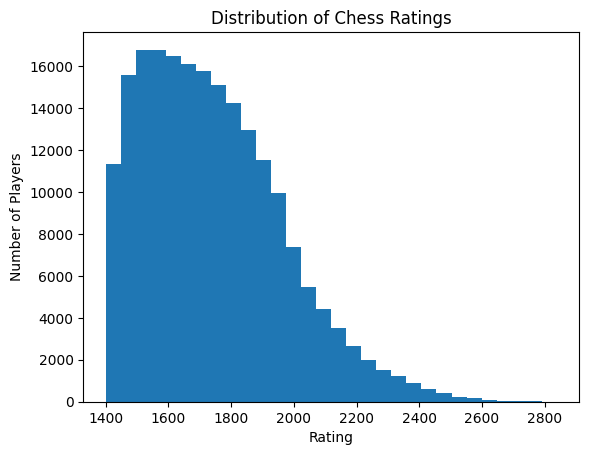

In [37]:
plt.hist(df["rating"], bins=30)

plt.title("Distribution of Chess Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Players")

plt.show()

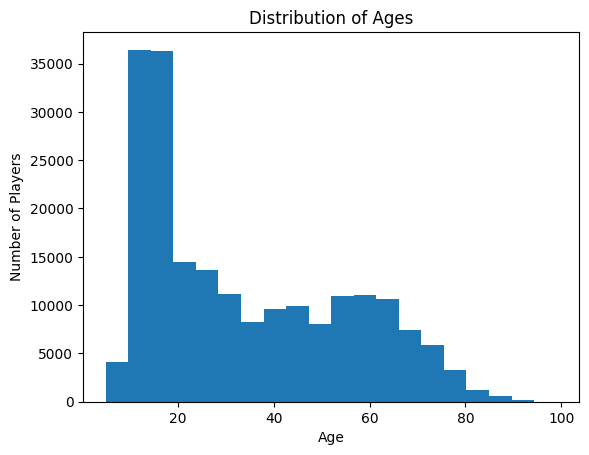

In [38]:
plt.hist(df["age"], bins=20)

plt.title("Distribution of Ages")
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.show()

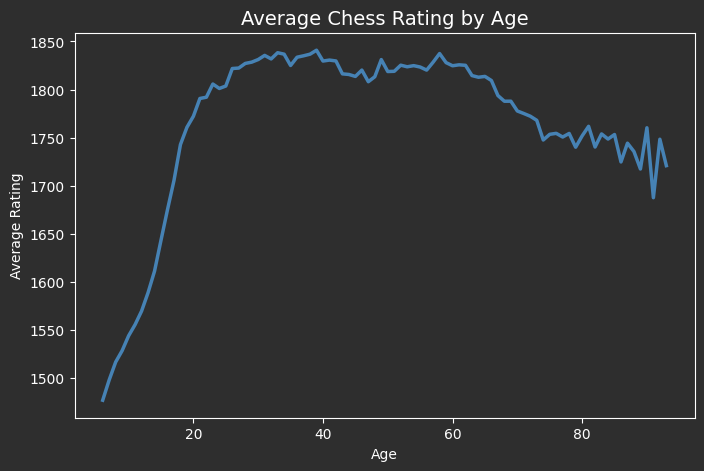

In [39]:
age_counts = df["age"].value_counts()

valid_ages = age_counts[age_counts >= 20].index

age_rating = df[df["age"].isin(valid_ages)].groupby("age")["rating"].mean()

plt.figure(figsize=(8,5), facecolor="#2E2E2E")
ax = plt.gca()
ax.set_facecolor("#2E2E2E")

plt.plot(age_rating.index, age_rating.values,
         color="steelblue",
         linewidth=2.5)

plt.title("Average Chess Rating by Age", color="white", fontsize=14)
plt.xlabel("Age", color="white")
plt.ylabel("Average Rating", color="white")


ax.tick_params(colors="white")


for spine in ax.spines.values():
    spine.set_color("white")

plt.show()

NameError: name 'male' is not defined

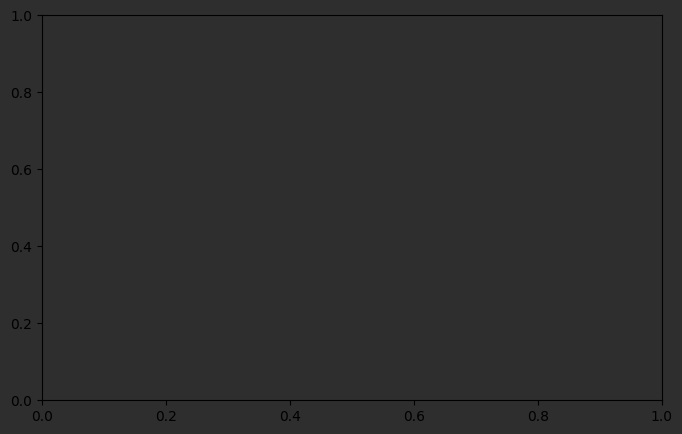

In [40]:
plt.figure(figsize=(8,5), facecolor="#2E2E2E")
ax = plt.gca()
ax.set_facecolor("#2E2E2E")

plt.plot(male.index, male.values,
         color="slateblue",
         linewidth=2.5,
         label="Male")

plt.plot(female.index, female.values,
         color="lightcoral",
         linewidth=2.5,
         label="Female")

plt.title("Average Chess Rating by Age and Gender",
          color="white",
          fontsize=14)

plt.xlabel("Age", color="white")
plt.ylabel("Average Rating", color="white")


ax.tick_params(colors="white")


for spine in ax.spines.values():
    spine.set_color("white")


legend = plt.legend()
legend.get_frame().set_facecolor("#2E2E2E")
legend.get_frame().set_edgecolor("white")

for text in legend.get_texts():
    text.set_color("white")

plt.show()

In [ ]:
from scipy import stats

In [ ]:
male_ratings = df[df["sex"] == "M"]["rating"]

female_ratings = df[df["sex"] == "F"]["rating"]

In [ ]:
t_stat, p_value = stats.ttest_ind(male_ratings,
                                  female_ratings,
                                  equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

In [ ]:
print("Number of male players:", len(male_ratings))
print("Number of female players:", len(female_ratings))

In [ ]:
print("Male average rating:", male_ratings.mean())
print("Female average rating:", female_ratings.mean())

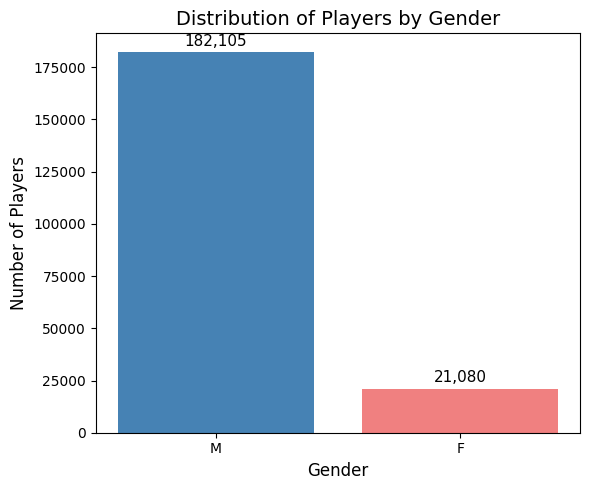

In [41]:
import matplotlib.pyplot as plt


gender_counts = df['sex'].value_counts()


plt.figure(figsize=(6,5))
plt.bar(gender_counts.index, gender_counts.values,
        color=['steelblue', 'lightcoral'])


plt.title('Distribution of Players by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)

for i, value in enumerate(gender_counts.values):
    plt.text(i, value + 3000, f'{value:,}',
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()